# 代码实现

我们来看FCN-8s的代码实现。这里，我们选择ResNet101作为模型的主干网络.

In [4]:
from torchvision import models

# 使用 ResNet101 作为主干网络，模型使用ImageNet预训练
pretrained_net = models.resnet101(pretrained='imagenet')

In [5]:
import torch.nn as nn

# FCN-8s模型
class FCN8s(nn.Module):
    def __init__(self, num_classes):
        super(FCN8s, self).__init__()
        # 这里使用children()调用ResNet101的部分网络
        # 该深度特征图的大小为输入图像的1/8
        self.stage1 = nn.Sequential(*list(pretrained_net.children())[:-4])
        # 该深度特征图的大小为输入图像的1/16
        self.stage2 = list(pretrained_net.children())[-4]
        # 该深度特征图的大小为输入图像的1/32
        self.stage3 = list(pretrained_net.children())[-3]
        
        # 调整stage3输出的通道数
        self.scores1 = nn.Conv2d(2048, num_classes, 1)
        # 调整stage2输出的通道数
        self.scores2 = nn.Conv2d(1024, num_classes, 1)
        # 调整stage1输出的通道数
        self.scores3 = nn.Conv2d(512, num_classes, 1)
        
        # 对pool3与pool4、pool5的输出进行8倍上采样
        self.upsample_8x = nn.ConvTranspose2d(
            num_classes, num_classes, 16, 8, 4, bias=False)
        self.upsample_8x.weight.data = bilinear_kernel(
            num_classes, num_classes, 16) # 使用双线性 kernel
        
        # 对pool4和pool5融合的特征2倍上采样
        self.upsample_4x = nn.ConvTranspose2d(
            num_classes, num_classes, 4, 2, 1, bias=False)
        self.upsample_4x.weight.data = bilinear_kernel(
            num_classes, num_classes, 4) # 使用双线性 kernel
        
        # 对pool5的输出2倍上采样
        self.upsample_2x = nn.ConvTranspose2d(
            num_classes, num_classes, 4, 2, 1, bias=False)   
        self.upsample_2x.weight.data = bilinear_kernel(
            num_classes, num_classes, 4) # 使用双线性 kernel

        
    def forward(self, x):
        x = self.stage1(x)
        # s1 1/8
        s1 = x
        
        x = self.stage2(x)
        # s2 1/16
        s2 = x

        x = self.stage3(x)
        # s3 1/32
        s3 = x
                
        # 调整pool5输出特征图的通道数
        s3 = self.scores1(s3)
        # 进行两倍上采样
        s3 = self.upsample_2x(s3)
        
        # 调整pool4输出特征图的通道数
        s2 = self.scores2(s2)
        # 融合pool5、pool4的特征图
        s2 = s2 + s3
        
        # 调整pool3输出特征图的通道数
        s1 = self.scores3(s1)
        # 将s2两倍上采样
        s2 = self.upsample_4x(s2)
        # 融合特征图
        s = s1 + s2
        
        # 8倍上采样得到与原图像大小一致的特征图
        s = self.upsample_8x(s2)
        return s
    

In [6]:
import os
import random
import cv2
import d2l.torch as d2l
from PIL import Image
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.autograd import Variable
from torchvision.transforms import transforms as tfs


根据原论文，使用Pascal Voc作为实验的数据集。

In [7]:
# 数据集地址
# 请读者自行下载数据集
voc_root = './voc/VOCdevkit/VOC2012'


# 定义Pascal Voc类
class VOCSegDataset(Dataset):
    def __init__(self, train, crop_size, transforms):
        # 定义数据大小
        self.crop_size = crop_size
        # 定义数据增强类型
        self.transforms = transforms
        
        # 数据以及对应标签的读取
        data_list, label_list = read_images(voc_root, train=train)
        self.data_list = self._filter(data_list)
        self.label_list = self._filter(label_list)
        print('Read'+str(len(self.data_list))+'images')
        
    def _filter(self, images):
        return [im for im in images if 
                (Image.open(im).size[1] >= self.crop_size[0] and
                Image.open(im).size[0] >= self.crop_size[1])]
    # 定义数据如何进行传输
    def __getitem__(self,idx):
        img = self.data_list[idx]
        label = self.label_list[idx]
        # 读取图像
        img = cv2.imread(img)
        # 将图像通道从BGR转换成RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        label = cv2.imread(label)
        # 因为标签与像素点一一对应，因此也需要将其进行转换
        label = cv2.cvtColor(label, cv2.COLOR_BGR2RGB)
        # 进行数据增强
        img,label = self.transforms(img, label, self.crop_size)
        return img, label
    
    def __len__(self):
        return len(self.data_list)

我们对上述类中出现的部分函数进行实现。

In [8]:
# 对上述数据集类的方法进行实现

# 读取数据集
def read_images(root, train=True):
    txt_filename = root + "/ImageSets/Segmentation/" \
        + ('train.txt' if train else 'val.txt')
    with open(txt_filename, 'r') as f:
        images = f.read().split()
    data = [os.path.join(root, 'JPEGImages', i + '.jpg') 
                                    for i in images]
    label = [os.path.join(root, 'SegmentationClass', i+'.png') 
                                    for i in images]
    return data, label


# 进行随机裁剪
def rand_crop(data, label, height,width):
    h, w, _ = data.shape
    top = random.randint(0, h - height)
    left = random.randint(0, w - width)
    # 裁剪数据
    data = data[top:top + height, left:left + width]
    # 裁剪标签
    label = label[top:top + height, left:left + width]
    return data, label


# 为图像增强时的像素点建立对应的标签
def image2label(im):
    data = np.array(im, dtype='int32')
    idx = (data[:,:,0] * 256 + data[:,:,1]) * 256 + data[:,:,2]
    return np.array(cm2lbl[idx], dtype='int64')


# 定义数据增强方法
def img_transforms(im, label, crop_size):
    im,label = rand_crop(im, label, *crop_size)
    im_tfs = tfs.Compose([
        tfs.ToTensor(),
        tfs.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    im = im_tfs(im)
    label = image2label(label)
    label = torch.from_numpy(label)
    return im, label



# 删除双线性插值函数中的输出
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = np.ogrid[:kernel_size, :kernel_size]
    filt = (1 - abs(og[0] - center) / factor) * \
        (1 - abs(og[1] - center) / factor)
    weight = np.zeros((in_channels, out_channels,
                       kernel_size, kernel_size), dtype='float32')
    weight[range(in_channels), range(out_channels),:,:] = filt
    return torch.from_numpy(weight)


接着，定义一些需要用到的全局变量，如类别信息等，并开始加载数据集，构建数据加载器。

In [9]:
# Pascal Voc的类别
classes = ['background','aeroplane','bicycle','bird','boat',
           'bottle','bus','car','cat','chair','cow','diningtable',
           'dog','horse','motorbike','person','potted plant',
           'sheep','sofa','train','tv/monitor']

# colormap的数量与类别数对应，每一种类别都有其独一无二的颜色，便于绘制图像时进行观察
colormap = [[0,0,0], [128,0,0], [0,128,0], [128,128,0], [0,0,128],
            [128,0,128], [0,128,128], [128,128,128], [64,0,0], 
            [192,0,0], [64,128,0], [192,128,0], [64,0,128], 
            [192,0,128], [64,128,128], [192,128,128], [0,64,0], 
            [128,64,0], [0,192,0], [128,192,0], [0,64,128]]

# 读取数据和标签
data, label = read_images(voc_root)
num_classes = len(classes)

# 将colormap转换成类别
cm2lbl = np.zeros(256**3)
for i, cm in enumerate(colormap):
    cm2lbl[(cm[0]*256+cm[1])*256+cm[2]]=i

# 设置输入图像大小
input_shape = (320,480)
voc_train = VOCSegDataset(True, input_shape, img_transforms)
voc_test = VOCSegDataset(False, input_shape, img_transforms)

Read1114images
Read1078images


In [10]:
#设置batch_size，生成数据加载器
BATCH_SIZE = 64
train_data = DataLoader(voc_train, batch_size=BATCH_SIZE, shuffle=True)
test_data = DataLoader(voc_test, batch_size=BATCH_SIZE)


先展示数据集中的部分图像与其对应的标签。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


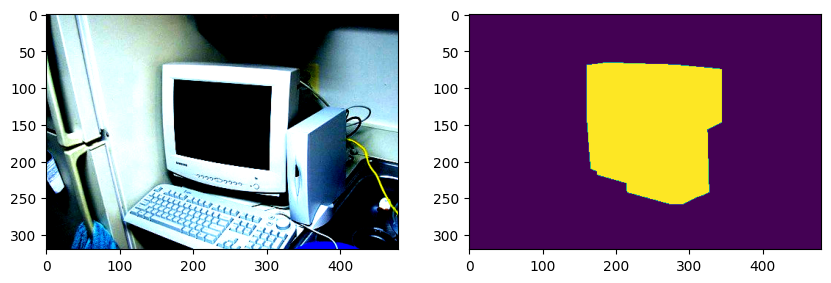

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


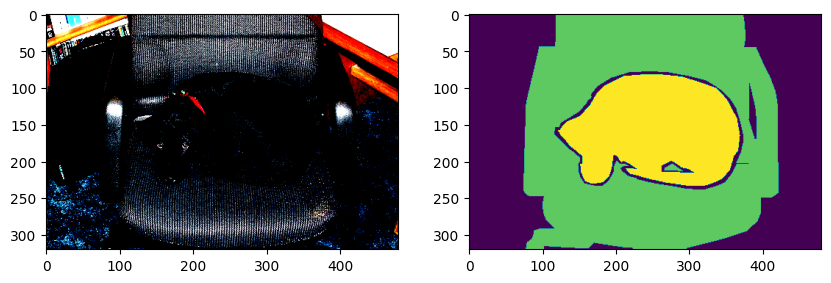

In [11]:
for i, (img, label) in enumerate(voc_train):
    plt.figure(figsize=(10, 10))
    plt.subplot(221)
    plt.imshow(img.moveaxis(0, 2))
    plt.subplot(222)
    plt.imshow(label)  
    plt.show()
    plt.close()
    if i ==1:
        break


接着，编写相关函数实现计算mIoU。

In [12]:
def _fast_hist(label_true, label_pred, n_class):
    mask = (label_true >= 0) & (label_true < n_class)
    hist = np.bincount(
        n_class * label_true[mask].astype(int) +
        label_pred[mask], minlength=n_class ** 2).reshape(
                                                n_class, n_class)
    return hist


def mIoU(label_trues, label_preds, n_class):
    # 计算mIoU
    hist = np.zeros((n_class, n_class))
    
    for lt, lp in zip(label_trues, label_preds):
        hist += _fast_hist(lt.flatten(), lp.flatten(), n_class)
        
    iu = np.diag(hist) / (hist.sum(axis=1) + 
                          hist.sum(axis=0) - np.diag(hist))
    mean_iu = np.nanmean(iu)

    return mean_iu

加载FCN-8s模型，并对其进行训练。

In [13]:
device = device = torch.device('cuda' if torch.cuda.is_available() 
                               else 'cpu')

# 加载模型 
model = FCN8s(num_classes)
model.to(device)
model = nn.DataParallel(model)

# 设置优化器
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, 
                            weight_decay=1e-4)

# 设置损失函数
criterion = nn.NLLLoss()


In [ ]:
# 由于没有验证集，这里每训练完一次模型便在测试集上进行测试

# 不显示无关信息
np.seterr(divide='ignore',invalid='ignore')


Epoch = 120
for epoch in range(Epoch):
    
    # 训练损失
    train_loss = 0
    # 训练mIoU
    train_mean_iu = 0
    
    # 开始训练
    model = model.train()

    for data in train_data:
        x = data[0].to(device)
        y = data[1].to(device)

        # 梯度清零
        optimizer.zero_grad()

        # 获得模型预测概率分布
        outputs = model(x)
        # 获得模型预测的标签，大小为(b,n,h,w)
        outputs = F.log_softmax(outputs, dim=1)
        
        # 计算损失
        loss = criterion(outputs, y)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        # 记录损失
        train_loss += loss.item()
        
        # 获得预测标签
        label_pred = outputs.max(dim=1)[1].data.cpu().numpy()
        label_true = y.data.cpu().numpy()
        
        for lbt, lbp in zip(label_true, label_pred):
            # 返回每张图的pred和gt标签计算mIoU
            mean_iu = mIoU(lbt, lbp, num_classes)
            train_mean_iu += mean_iu
    

    # 测试损失
    eval_loss = 0
    # 测试mIoU
    eval_mean_iu = 0
    
    # 进行模型测试
    model = model.eval()
    
    for data in test_data:
        x_test = data[0].to(device)
        y_test = data[1].to(device)
        outputs_test = model(x_test)
        outputs_test = F.log_softmax(outputs_test, dim=1)
        
        loss = criterion(outputs_test, y_test)
        eval_loss += loss.item()
        
        label_pred = outputs_test.max(dim=1)[1].data.cpu().numpy()
        label_true = y_test.data.cpu().numpy()
        
        for lbt, lbp in zip(label_true, label_pred):
            mean_iu = mIoU(lbt, lbp, num_classes)
            eval_mean_iu += mean_iu
        
    epoch_str = ('Epoch: {}, Train Loss: {:.5f}, Train Mean IU: {:.5f},\
                 Valid Loss: {:.5f}, Valid Mean IU: {:.5f} '.format(
                epoch, train_loss / len(train_data), 
                train_mean_iu / len(voc_train), 
                eval_loss / len(test_data), 
                eval_mean_iu / len(voc_test)))
   
    print(epoch_str)


为了方便，在这里不展示具体的训练信息输出。接着，随机选择一些图像，并展示其真实标签与模型的预测标签。

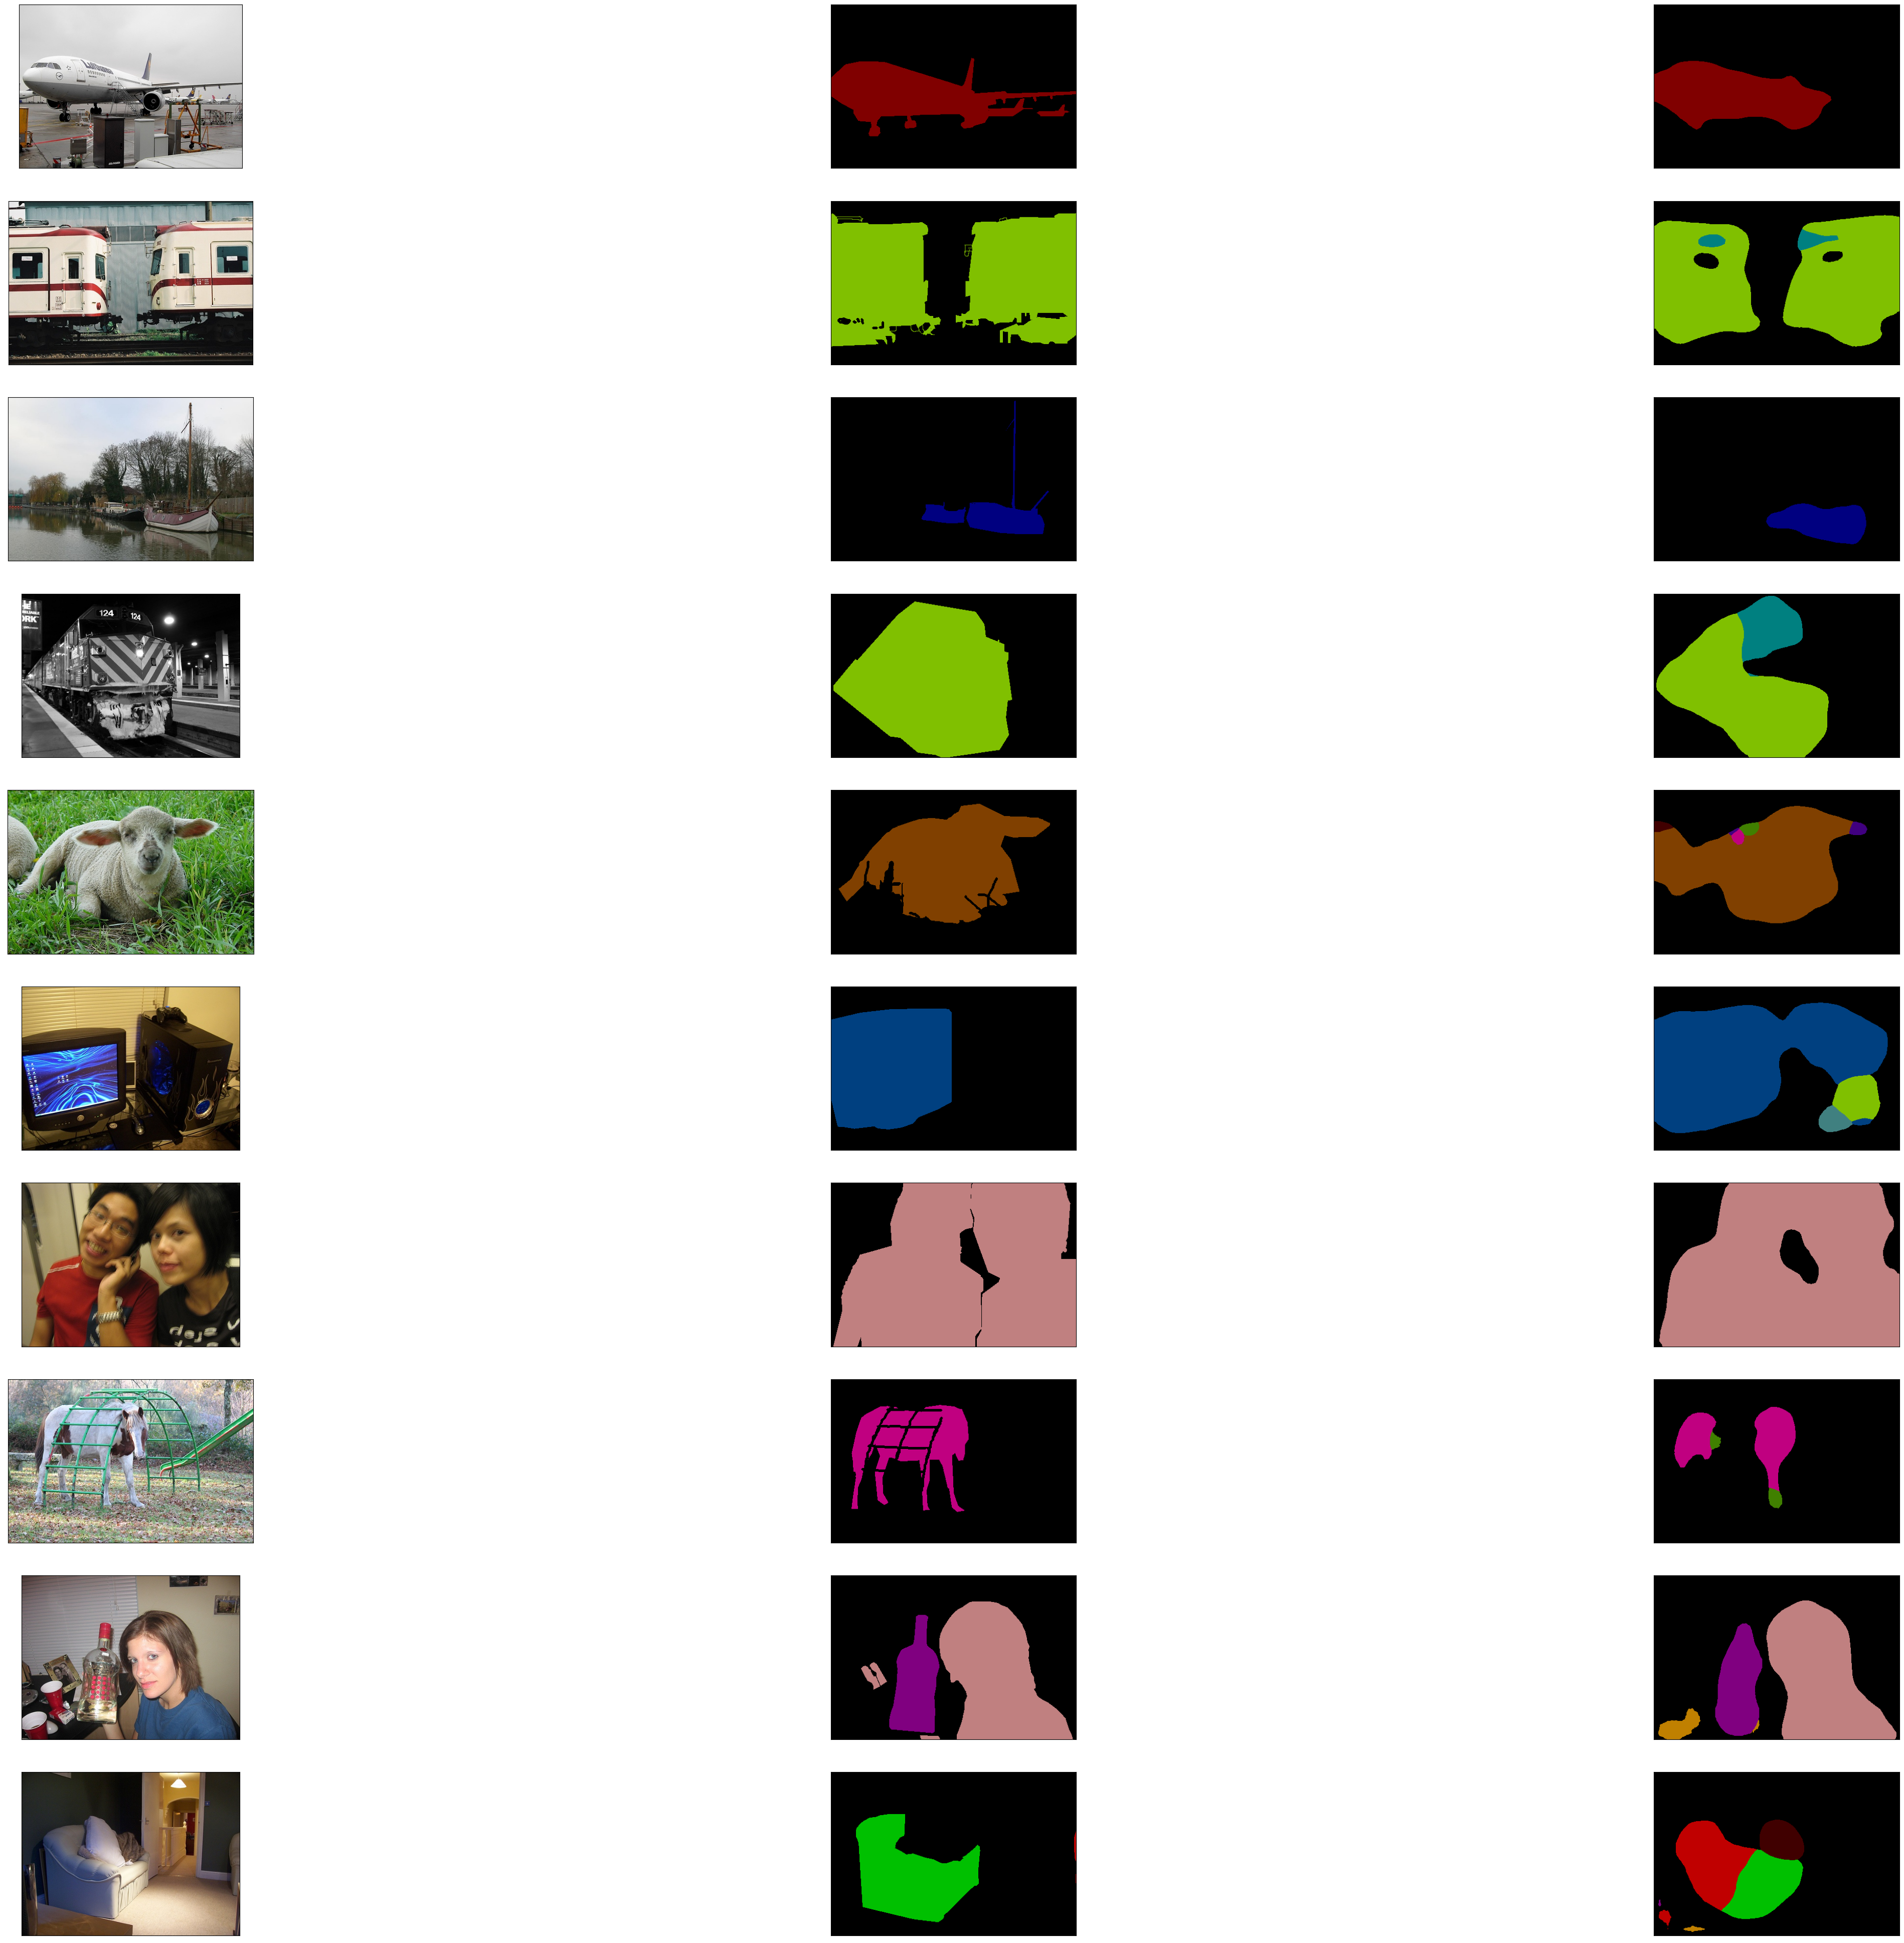

In [17]:
# 将预测的标签映射到colormap上
cm = np.array(colormap).astype('uint8')

def predict(im, label):
    im = Variable(im.unsqueeze(0)).cuda()
    out = model(im)
    pred = out.max(1)[1].squeeze().cpu().data.numpy()
    pred = cm[pred]
    return pred, cm[label.numpy()]


_, figs = plt.subplots(10, 3, figsize=(12, 10))

for i in range(10):
    x, y = voc_test[i]
    x.to(device)
    y.to(device)
    pred, label = predict(x, y)
    figs[i, 0].imshow(Image.open(voc_test.data_list[i]))
    figs[i, 0].axes.get_xaxis().set_visible(False)
    figs[i, 0].axes.get_yaxis().set_visible(False)
    figs[i, 1].imshow(label)
    figs[i, 1].axes.get_xaxis().set_visible(False)
    figs[i, 1].axes.get_yaxis().set_visible(False)
    figs[i, 2].imshow(pred)
    figs[i, 2].axes.get_xaxis().set_visible(False)
    figs[i, 2].axes.get_yaxis().set_visible(False)